# **APRENDIZAGEM SUPERVISIONADA: REGRESSÃO**

In [80]:
import pandas as pd
import numpy as np


In [81]:
df = pd.read_csv('housing.csv')
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [82]:
df.shape

(489, 4)

## **EXPLORAÇÃO E TRATAMENTO DE DADOS**

Valores Missing (NAN)

In [83]:
# Relação da quantidade
df.isnull().sum()

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

**Análise dos atributos**

In [84]:
df.dtypes



RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

**Dados Estatísticos**

In [85]:
df.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


**Análise de Outliers**

In [86]:
import plotly.express as px


In [87]:
boxplot = px.box(df, y="RM")
boxplot.show()

In [88]:
boxplot = px.box(df, y="LSTAT")
boxplot.show()

In [89]:
boxplot = px.box(df, y="PTRATIO")
boxplot.show()

In [90]:
boxplot = px.box(df, y="MEDV")
boxplot.show()

## **CORRELAÇÃO LINEAR**

In [91]:
import matplotlib.pyplot as plt

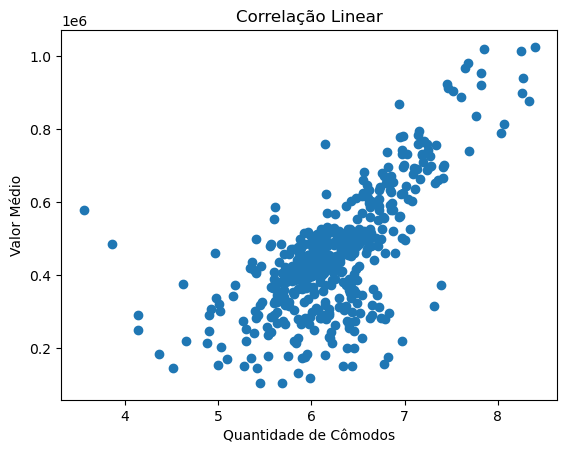

In [92]:
plt.scatter(df["RM"], df["MEDV"])
plt.title("Correlação Linear")
plt.xlabel("Quantidade de Cômodos")
plt.ylabel("Valor Médio")
plt.grid(False)
plt.show()

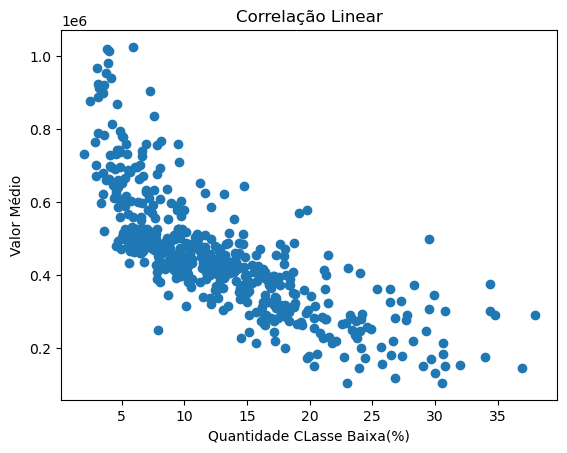

In [93]:
plt.scatter(df["LSTAT"], df["MEDV"])
plt.title("Correlação Linear")
plt.xlabel("Quantidade CLasse Baixa(%)")
plt.ylabel("Valor Médio")
plt.grid(False)
plt.show()

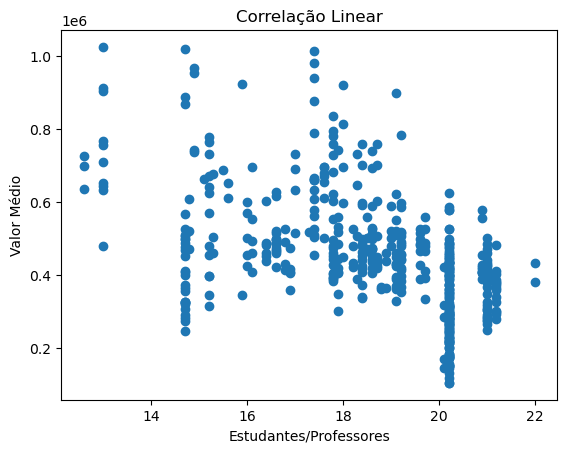

In [94]:
plt.scatter(df["PTRATIO"], df["MEDV"])
plt.title("Correlação Linear")
plt.xlabel("Estudantes/Professores")
plt.ylabel("Valor Médio")
plt.grid(False)
plt.show()

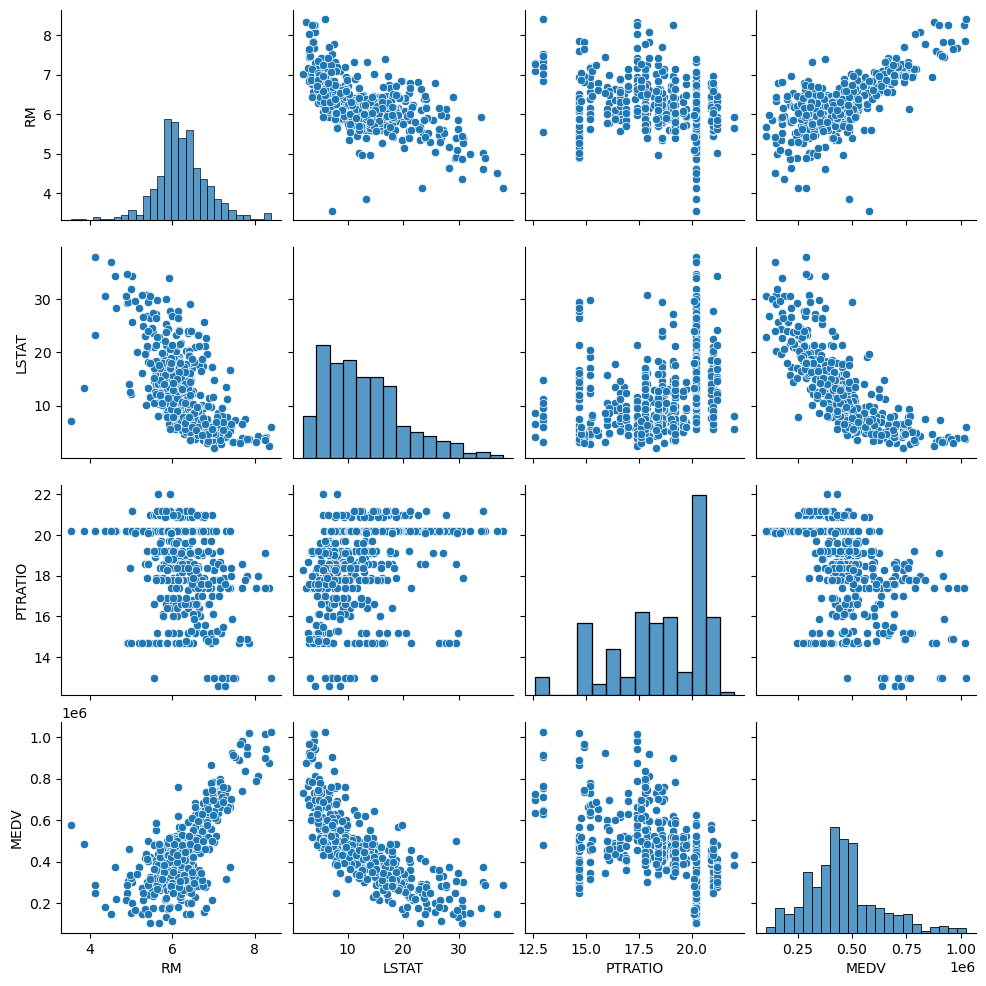

In [95]:
import seaborn as sns
sns.pairplot(df)
plt.show()


**Análise da Normalidade**

Gráfico QQ-Plot

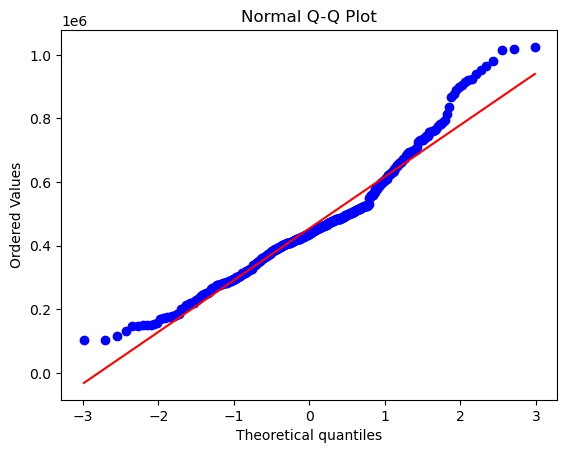

In [96]:
import scipy.stats as stats
stats.probplot(df["MEDV"], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

In [97]:
import plotly.express as px

In [98]:
hist = px.histogram(df, x="MEDV", nbins=60)
hist.update_layout(width=800, height=500, title_text="Média dos Valores")
hist.show()

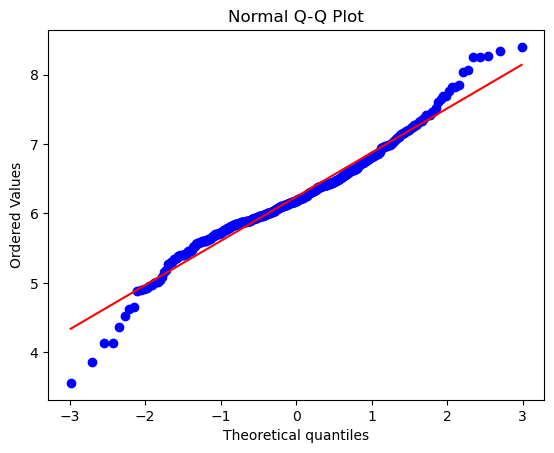

In [99]:
stats.probplot(df["RM"], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

In [100]:
hist = px.histogram(df, x="RM", nbins=60)
hist.update_layout(width=800, height=500, title_text="Quantidade de Cômodos")
hist.show()

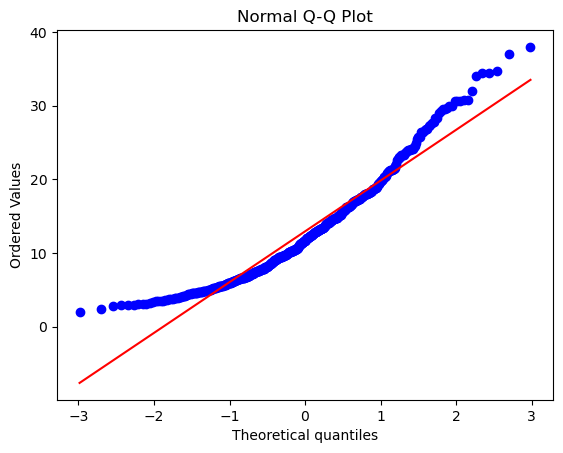

In [101]:
stats.probplot(df["LSTAT"], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

In [102]:
hist = px.histogram(df, x="LSTAT", nbins=60)
hist.update_layout(width=800, height=500, title_text="Quantidade de Classe Baixa(%)")
hist.show()

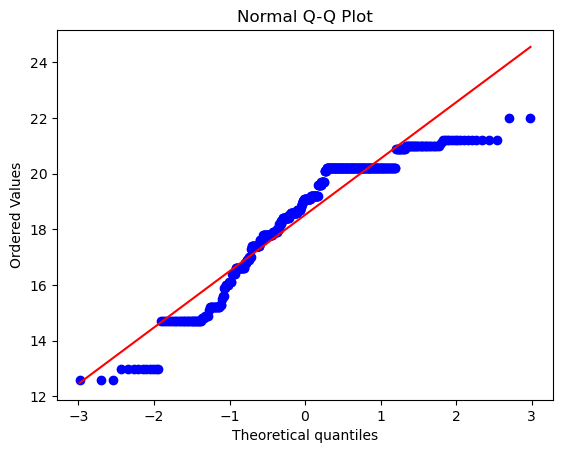

In [103]:
stats.probplot(df["PTRATIO"], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

In [104]:
hist = px.histogram(df, x="PTRATIO", nbins=60)
hist.update_layout(width=800, height=500, title_text="Relação Estudantes/Professores")
hist.show()

Teste de Shapiro-Wilk

Ho = distribuição normal : p > 0.05

Ha = distribuição não normal : p <= 0.05

In [106]:
estatistica, p_valor = stats.shapiro(df["MEDV"])
print(f"Estatística: {estatistica}, P-valor: {p_valor}")

Estatística: 0.9596616055953767, P-valor: 2.5759801704018553e-10


In [107]:
estatistica, p_valor = stats.shapiro(df["RM"])
print(f"Estatística: {estatistica}, P-valor: {p_valor}")

Estatística: 0.9708170375303297, P-valor: 2.7090145811327798e-08


In [108]:
estatistica, p_valor = stats.shapiro(df["LSTAT"])
print(f"Estatística: {estatistica}, P-valor: {p_valor}")

Estatística: 0.9371757140975832, P-valor: 1.689879707182205e-13


In [109]:
estatistica, p_valor = stats.shapiro(df["PTRATIO"])
print(f"Estatística: {estatistica}, P-valor: {p_valor}")

Estatística: 0.90647424903615, P-valor: 9.064596547331122e-17


Teste Lilliefors (Kolmogorov_Sminorv)

Ho = distribuição normal : p > 0.05

Ha = distribuição != normal : p <= 0.05

In [110]:
import statsmodels
from statsmodels.stats.diagnostic import lilliefors

In [111]:
estatistica, p = statsmodels.stats.diagnostic.lilliefors(df.MEDV, dist = 'norm')
print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística de teste: 0.11370576407672117
p-valor: 0.0009999999999998899


### **Correlação Linear** 

Pearson (distribuição normal)

Spearman (distribuição não normal)

Kendall (distribuição não normal com quantidade pequena de amostras)

Ho = não há corrrelação linear: p > 0,05

Ha = existe correlação linear: p <= 0,05

In [ ]:
# Pearson
#coef,p = stats.pearsonr(df.MEDV, df.RM)
#print('Coeficiente de correlação: {}'.format(coef))
#print('p-valor: {}'.format(p))

In [114]:
# Spearman
coef,p = stats.spearmanr(df.MEDV, df.PTRATIO)
print('Coeficiente de correlação: {}'.format(coef))
print('p-valor: {}'.format(p))

Coeficiente de correlação: -0.5592761164167336
p-valor: 1.3794858687631326e-41


In [115]:
# Kendall
#coef,p = stats.kendalltau(df.MEDV,df.RM)
#print('Coeficiente de correlação: {}'.format(coef))
#print('p-valor: {}'.format(p))

In [116]:
correlacoes = df.corr(method='spearman')
correlacoes

,RM,LSTAT,PTRATIO,MEDV
RM,1.000000,-0.624700,-0.282053,0.624057
LSTAT,-0.624700,1.000000,0.461739,-0.845527
PTRATIO,-0.282053,0.461739,1.000000,-0.559276
MEDV,0.624057,-0.845527,-0.559276,1.000000


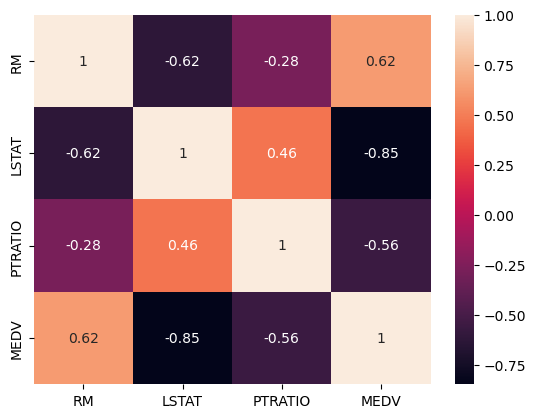

In [117]:
plt.figure()
sns.heatmap(correlacoes, annot=True);